In [1]:
%load_ext autoreload
%autoreload 2

# Combined Trend Strategy

## Hypothesis
We are testing a combination of 3 strategies.
1. Trend Following
2. Split Trend Following
3. Vol Reduction

### 1. Trend Following
We theorize the existence of trend / momentum premium, where we can obtain better risk-adjusted returns by going long the asset when recent returns are positive and going short the asset when recent returns are negative.

The momentum premium is well-documented in literature, even though the source of the premium is still being debated.

### 2. Split Trend Following
We note that the trend following strategy has a key parameter, which is the lookback period for which we calculate the recent returns. The optimal value of this parameter is dependent on market conditions. Attempting to optimize this parameter based on historical backtesting likely leads to over-fitting.

We propose to adjust our position based on multiple lookback periods as a weighted-sum of the signals suggested by each lookback period.

### 3. Vol Reduction
We propose to reduce the volatility of returns by reducing position during volatile periods. Using recent volatility and VIX-measures as a proxy for forward volatility, we can compute the forward variance and use it to adjust our position, reducing our exposure when forward volatility is high. This should help us to reduce our exposure during volatile economic periods and lead to better risk-adjusted returns.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
from utils.backtester import BackTester
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from utils.data_fetcher import YahooDataFetcher, TickerPriceDataFetcher
import datetime
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit
import lightgbm as lgb
import optuna
from indicators.returns import calculate_binary_forward_returns, calculate_binary_returns, calculate_binary_MA_returns, calculate_forward_returns, calculate_returns, calculate_MA_returns
from indicators.breakout import calculate_breakout
from indicators.volatility import calculate_atr, calculate_forward_vol
from indicators.volume import calculate_rel_volume
from indicators.trend import calculate_r2
import backtrader as bt
from strategies.base import BaseStrategy
import os
import numpy as np
from sklearn.preprocessing import MinMaxScaler

Warning - Certain functionality 
             requires requests_html, which is not installed.
             
             Install using: 
             pip install requests_html
             
             After installation, you may have to restart your Python session.


## Utility Functions

In [3]:
def load_data(data):
    
    fetcher = TickerPriceDataFetcher()  
    asset_list = data['asset_list']
    ticker_list = asset_list + [data[ticker]['vol_measure'] for ticker in data['asset_list']]
    ticker_list.append('SHV')
    price_data = fetcher.load_data(ticker_list=ticker_list)
    
    for ticker in asset_list:
        vol_ticker = data[ticker]['vol_measure']
        df = price_data[ticker].copy()
        df_vol = price_data.get(vol_ticker)
        if df_vol is None:
            print(f'{vol_ticker} not found')
        else:
            df['vix'] = df_vol['close'].copy()
        data[ticker]['data'] = df.copy()

    ticker = 'SHV'
    data[ticker]['data'] = price_data[ticker].copy()
        
    return data




## Load Data

In [4]:
data = {
    'asset_list': ['SPY', 'TLT', 'GLD'],
    'SPY': {
        'vol_measure': '^VIX',
        'data': None,
    },
    'GLD': {
        'vol_measure': '^GVZ',
        'data': None,
    },
    'TLT': {
        'vol_measure': '^VXTLT',
        'data': None,
    },
    'SHV': {
        'data': None,
    },
    'current_date': None,
}


# Current date
current_date = datetime.datetime.now().date()
current_date = current_date.strftime("%Y%m%d")
data['current_date'] = current_date


data = load_data(data)

INFO:utils.data_fetcher:Loading data for ['SPY', 'TLT', 'GLD', '^VIX', '^VXTLT', '^GVZ', 'SHV']
INFO:utils.data_fetcher:Fetching data for SPY with yfinance
INFO:utils.data_fetcher:Moved SPY_20250411.pkl to archive
INFO:utils.data_fetcher:Fetching data for TLT with yfinance
INFO:utils.data_fetcher:Moved TLT_20250411.pkl to archive
INFO:utils.data_fetcher:Fetching data for GLD with yfinance
INFO:utils.data_fetcher:Moved GLD_20250411.pkl to archive
INFO:utils.data_fetcher:Fetching data for ^VIX with yfinance
INFO:utils.data_fetcher:Moved ^VIX_20250411.pkl to archive
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yfinance
ERROR:yfinance:^VXTLT: Period 'max' is invalid, must be of the format 1d, 5d, etc.
INFO:utils.data_fetcher:Fetching data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT with yahoo_fin
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
ERROR:utils.data_fetcher:Failed to fetch data for ^VXTLT
INFO:utils.data_fetcher:Fetching d

^VXTLT not found


## Parameters

In [5]:
lookforward_period = 21
lookback_periods = [21, 100, 252]
rebalance_period = 21
capital = 62847
leverage = 2
atr_period = 14


## Data Preprocessing

In [6]:
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()
    df_data['returns'] = df_data['close'].pct_change()
    df_data['vol_forward'] = calculate_forward_vol(df_data, lookforward_period)
    df_data['ret_forward'] = calculate_forward_returns(df_data, lookforward_period)
    df_data['ATR'] = calculate_atr(df_data, 14)
    annualized_vol = df_data['returns'].std() * np.sqrt(252)
    annualized_var = annualized_vol ** 2
    
    ##############################################################
    # Variance Scale
    ##############################################################
    df_data['var_forward'] = df_data['vol_forward'] ** 2
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_data['var_forward_scaled'] = scaler.fit_transform(df_data['var_forward'].values.reshape(-1, 1))
    data[ticker]['annualized_var'] = annualized_var
    data[ticker]['annualized_vol'] = annualized_vol
    data[ticker]['var_scaler'] = scaler

    ##############################################################
    # Save
    ##############################################################
    data[ticker]['data'] = df_data

  0%|          | 0/3 [00:00<?, ?it/s]

SPY
TLT
GLD


## Test Strategies

### Trend Following

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


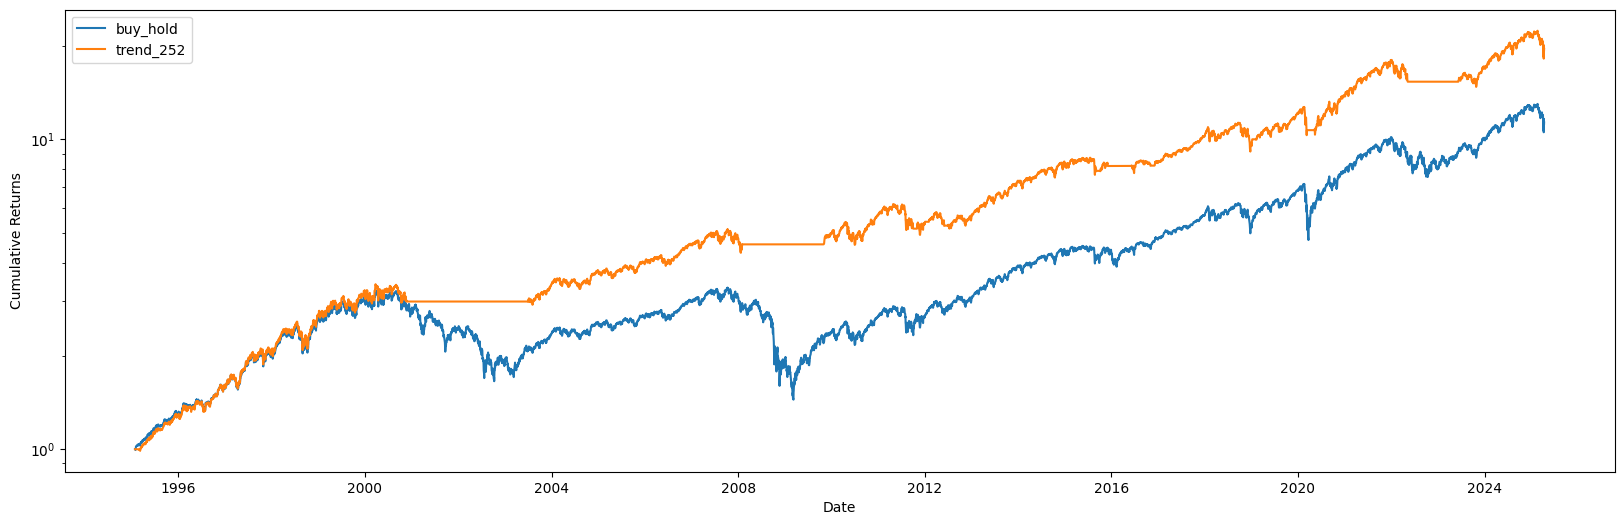

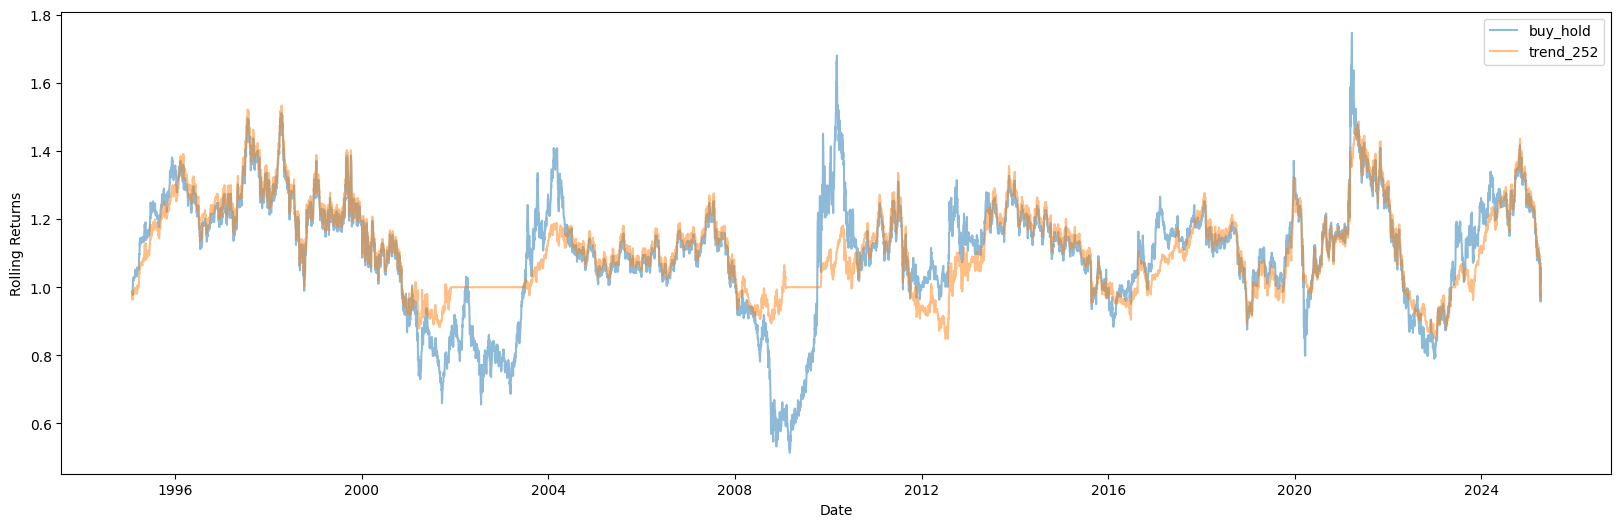

buy_hold
CAGR:           8.38%
Volatility:     19.22%
Sharpe Ratio:   0.44
--------------------------------------------
trend_252
CAGR:           10.36%
Volatility:     13.93%
Sharpe Ratio:   0.74
--------------------------------------------
TLT


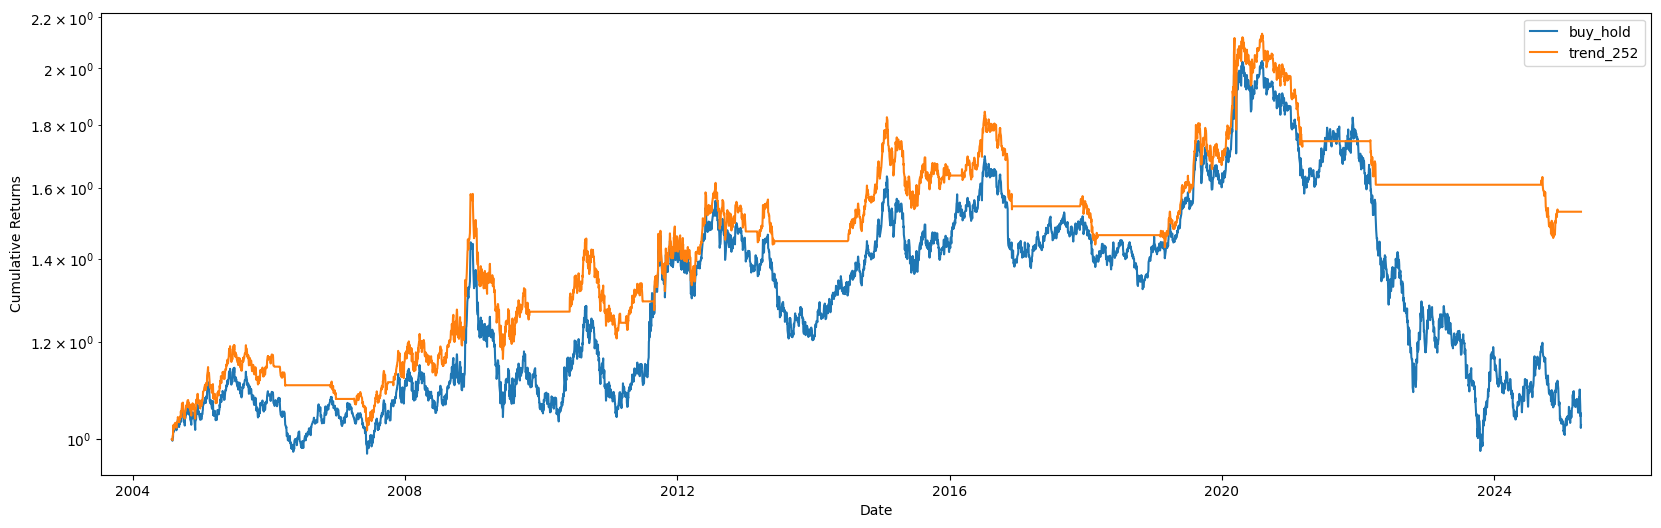

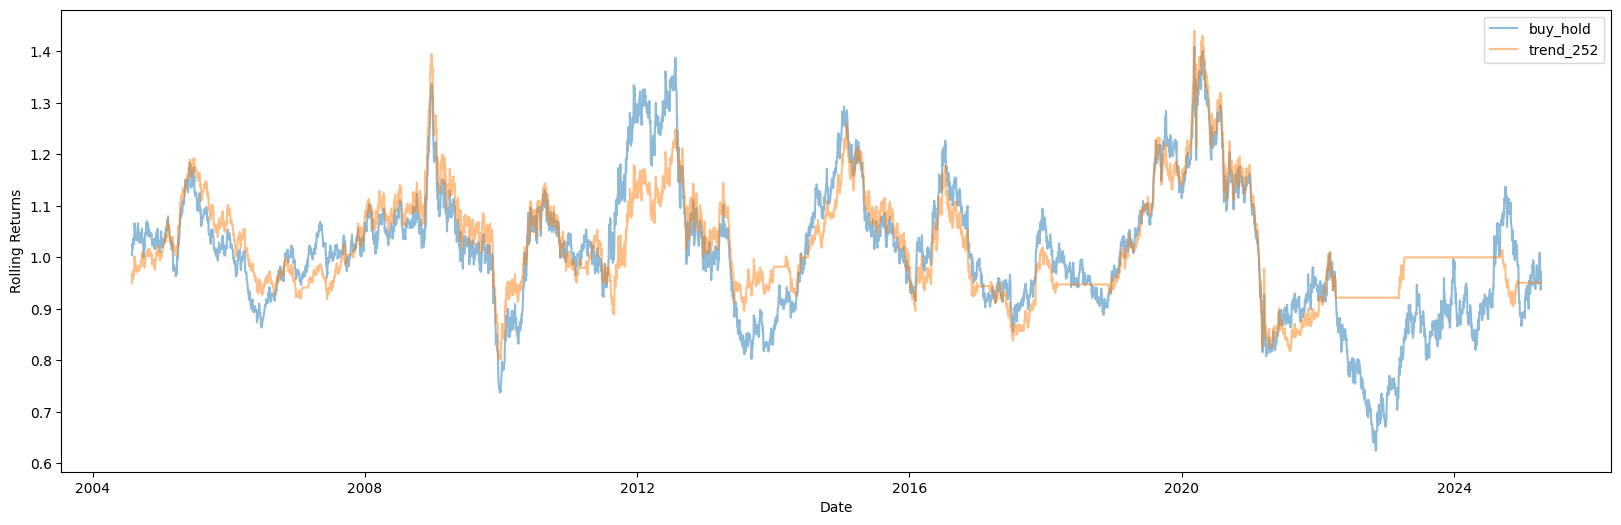

buy_hold
CAGR:           0.13%
Volatility:     14.73%
Sharpe Ratio:   0.01
--------------------------------------------
trend_252
CAGR:           2.08%
Volatility:     11.47%
Sharpe Ratio:   0.18
--------------------------------------------
GLD


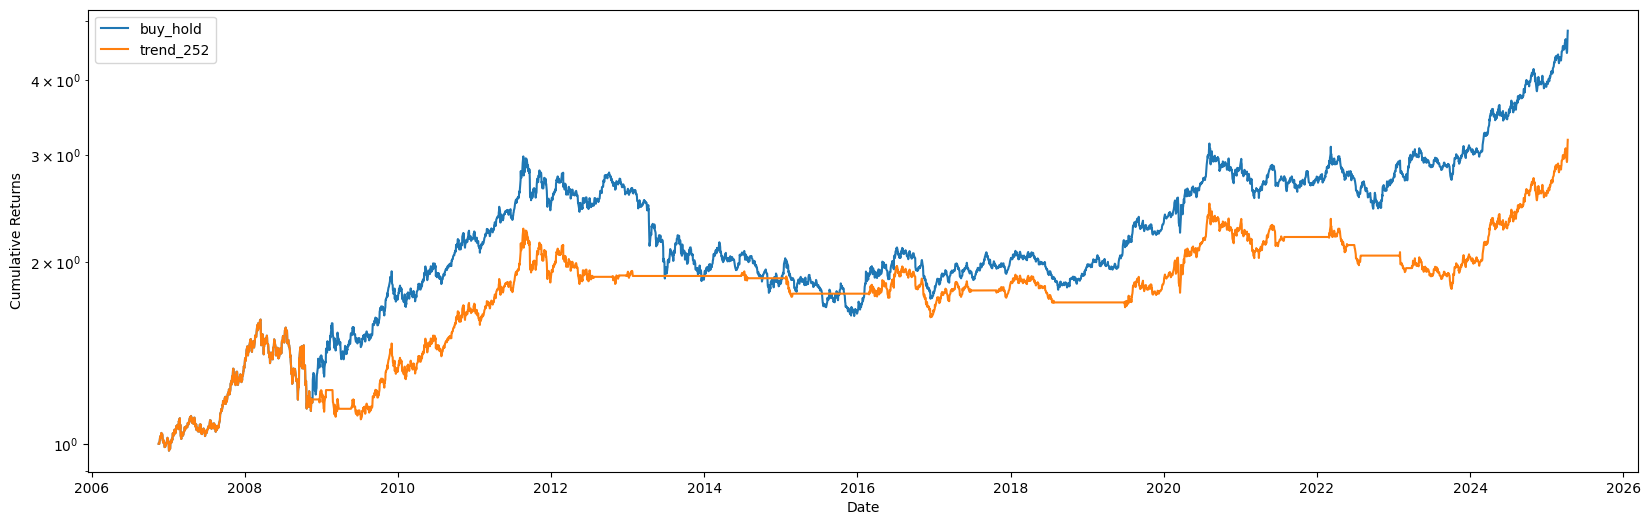

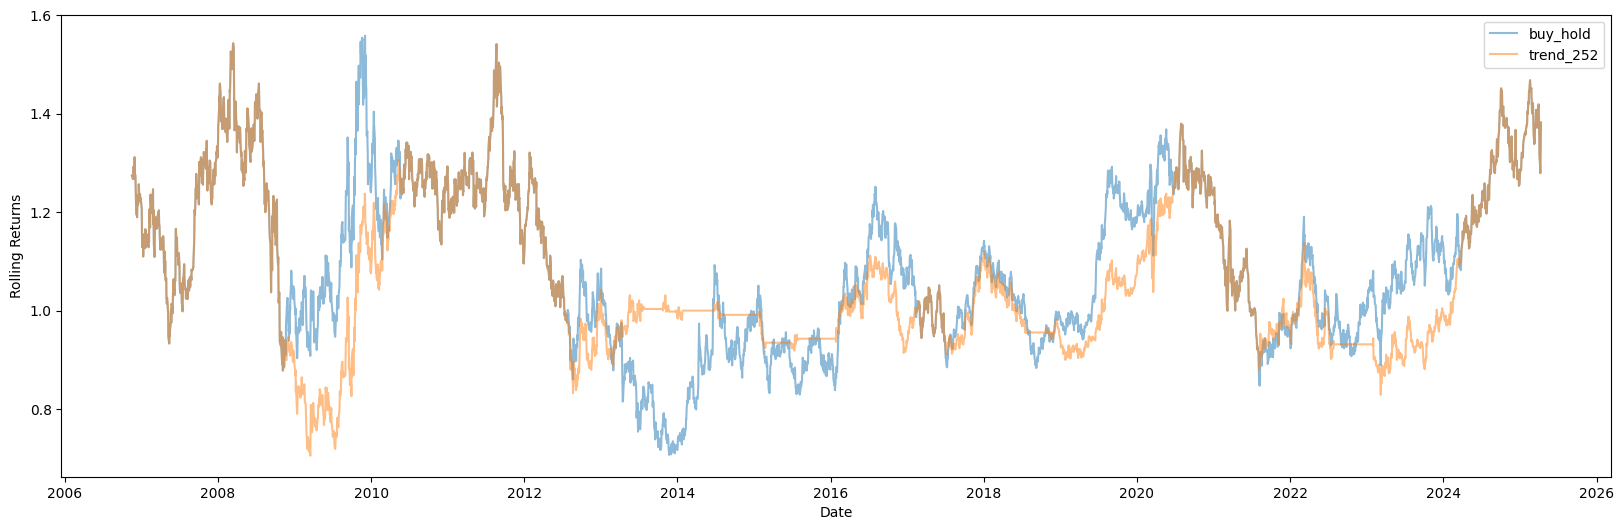

buy_hold
CAGR:           8.94%
Volatility:     17.33%
Sharpe Ratio:   0.52
--------------------------------------------
trend_252
CAGR:           6.51%
Volatility:     14.59%
Sharpe Ratio:   0.45
--------------------------------------------


In [7]:
class TrendFollowingStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_period', 21),  # Default 1-month lookback (21 trading days)
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        self.returns = bt.indicators.PercentChange(self.data.close, period=self.p.lookback_period)
        self.rebalance_day = 0

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            if self.returns[0] > 0:
                target_position = self.broker.getvalue() / self.data.close[0]
            else:
                target_position = 0
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendFollowingStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        lookback_period=252
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_252')
    compare_returns(plot=True)

### Trend Split

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


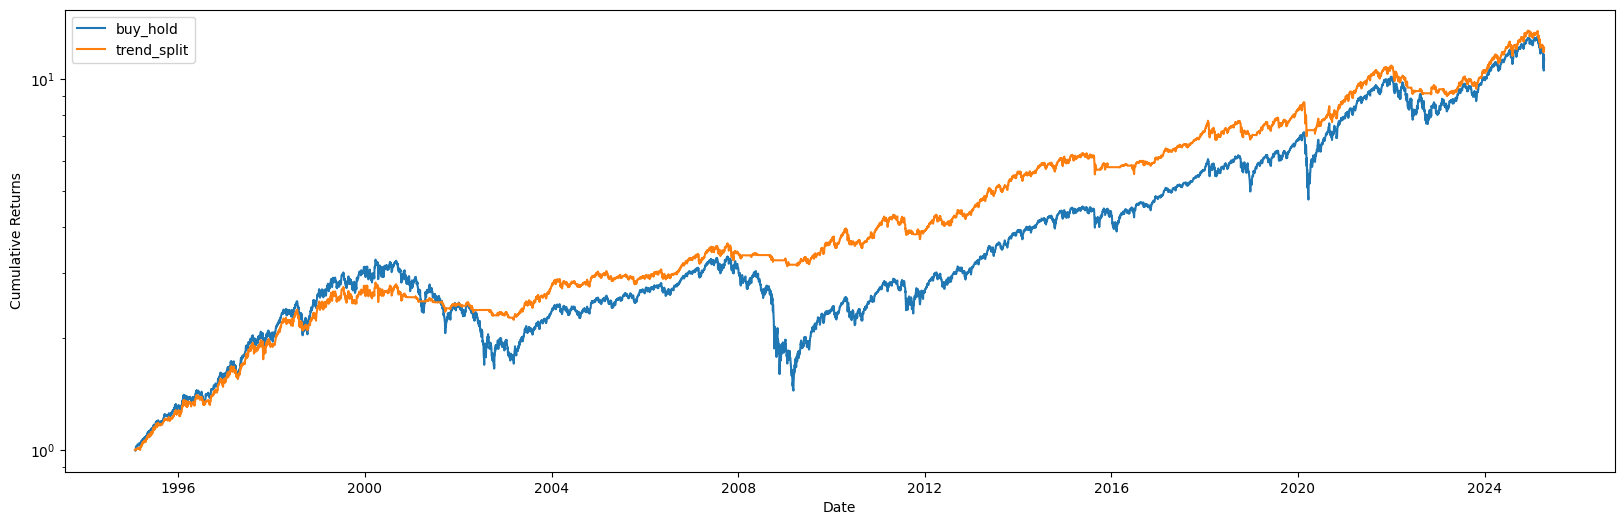

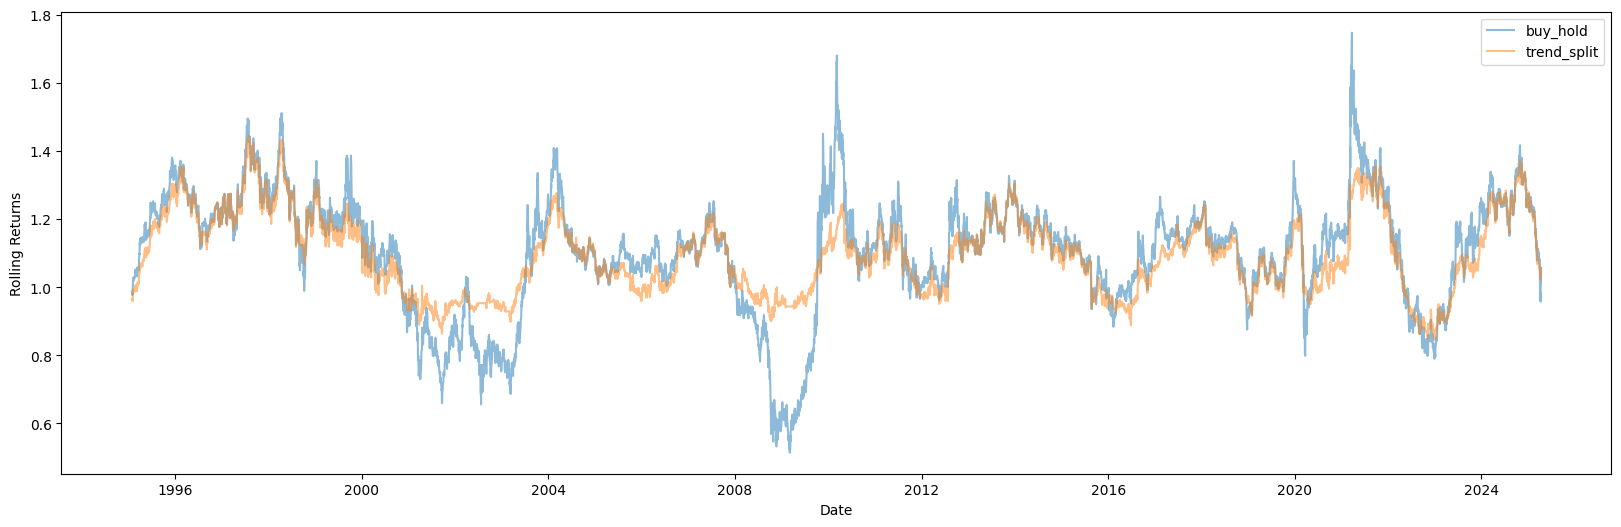

buy_hold
CAGR:           8.38%
Volatility:     19.22%
Sharpe Ratio:   0.44
--------------------------------------------
trend_split
CAGR:           8.61%
Volatility:     11.64%
Sharpe Ratio:   0.74
--------------------------------------------
TLT


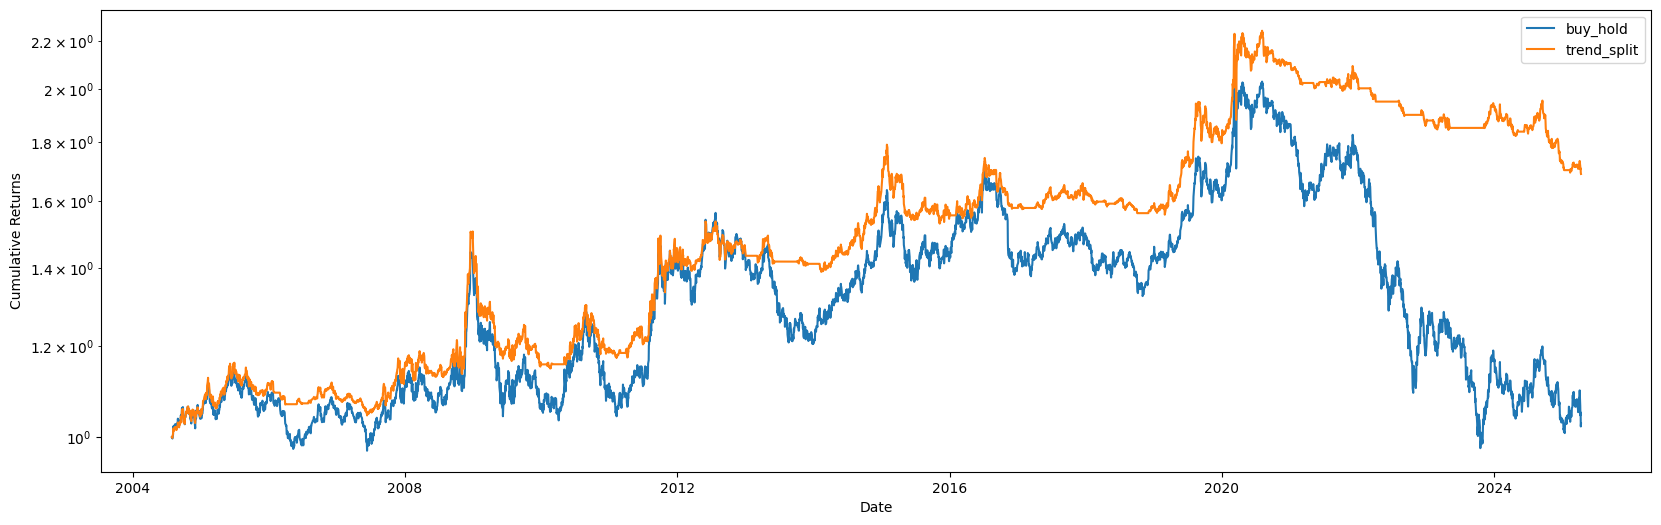

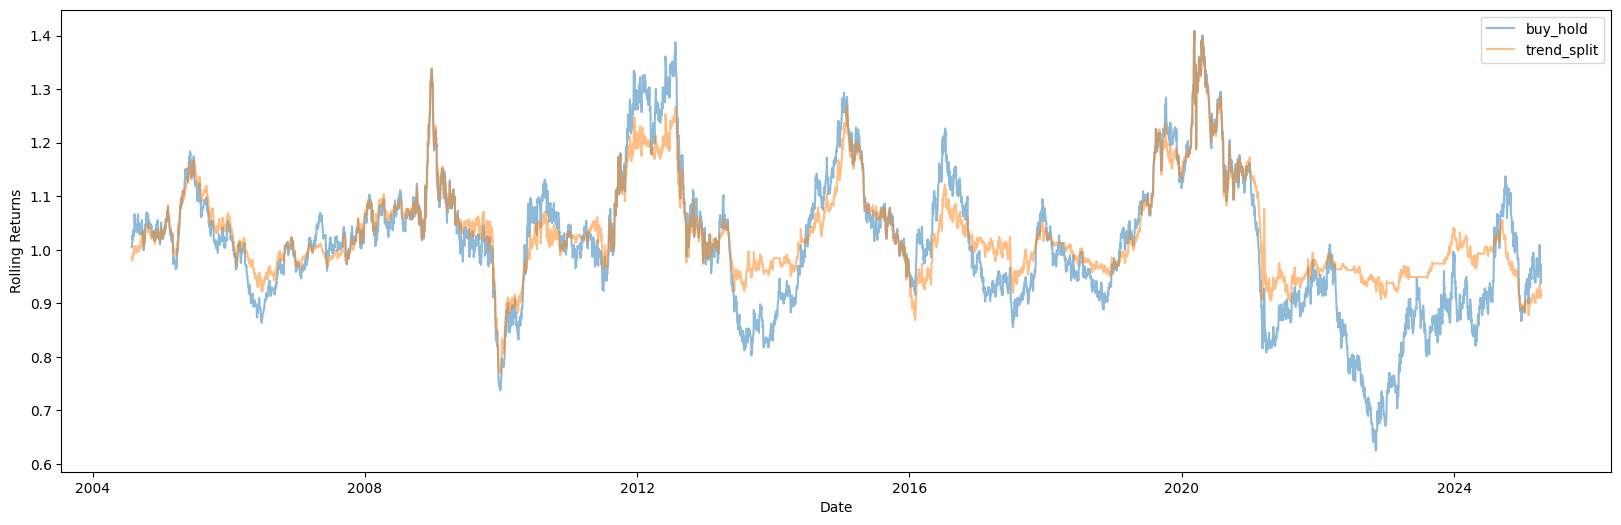

buy_hold
CAGR:           0.13%
Volatility:     14.73%
Sharpe Ratio:   0.01
--------------------------------------------
trend_split
CAGR:           2.56%
Volatility:     9.92%
Sharpe Ratio:   0.26
--------------------------------------------
GLD


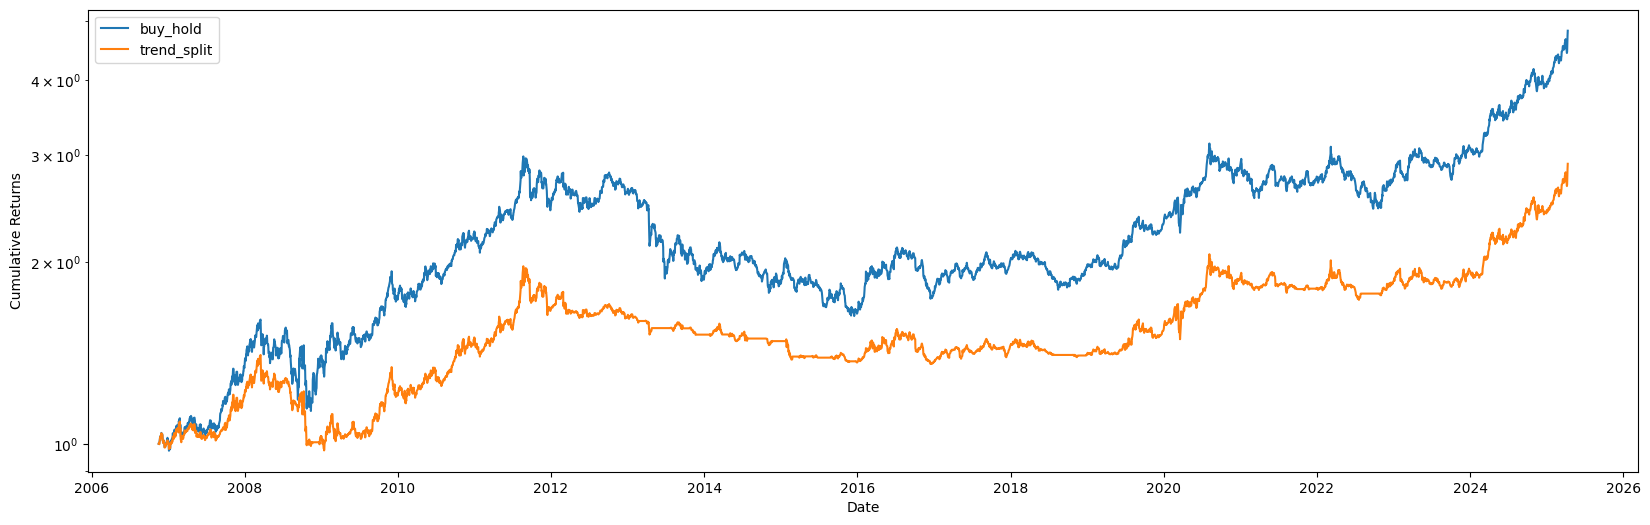

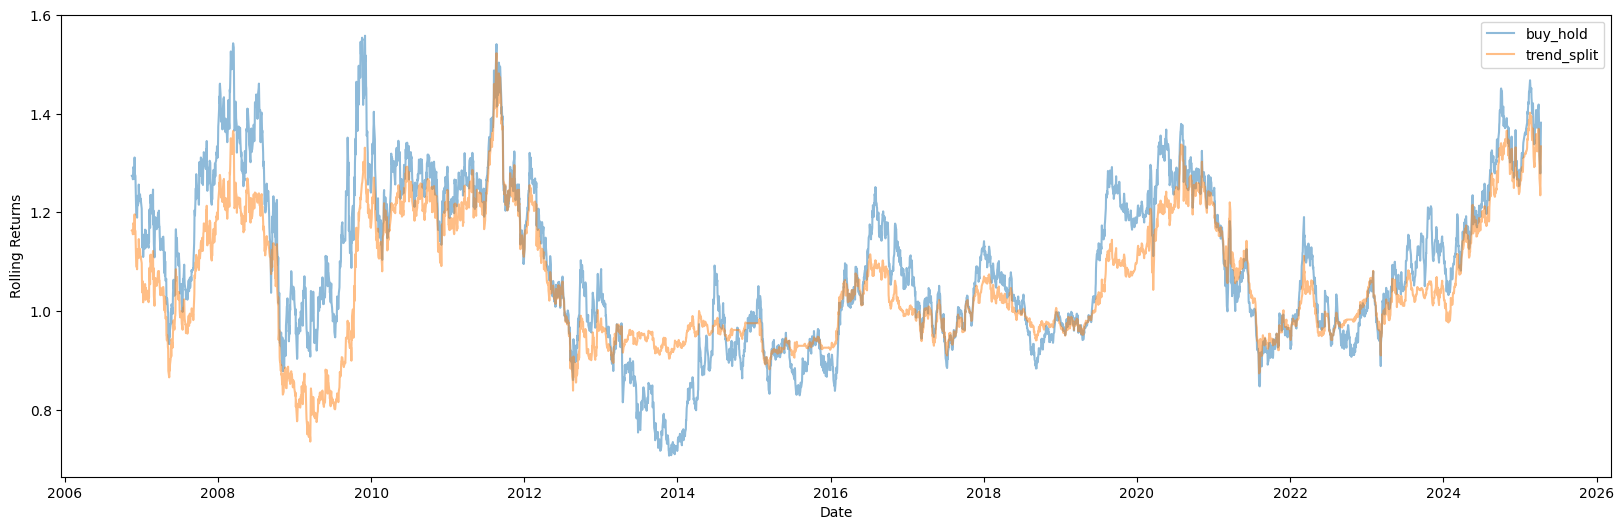

buy_hold
CAGR:           8.94%
Volatility:     17.33%
Sharpe Ratio:   0.52
--------------------------------------------
trend_split
CAGR:           5.98%
Volatility:     12.69%
Sharpe Ratio:   0.47
--------------------------------------------


In [8]:
class TrendSplitStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_periods', [21, 252]),
        ('rebalance_period', 21),  # Rebalance period in days
    )

    def __init__(self):
        super().__init__()
        self.returns = dict()
        for period in self.p.lookback_periods:
            self.returns[period] = bt.indicators.PercentChange(self.data.close, period=period)
        self.weight = 1 / len(self.p.lookback_periods)
        self.rebalance_day = 0

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 0.0        
            for period in self.p.lookback_periods:
                if self.returns[period][0] > 0:
                    target_size += self.weight
            target_position = target_size * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
            
        self.rebalance_day += 1


combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendSplitStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        lookback_periods=lookback_periods
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_split')
    compare_returns(plot=True)

### Vol Reduction

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


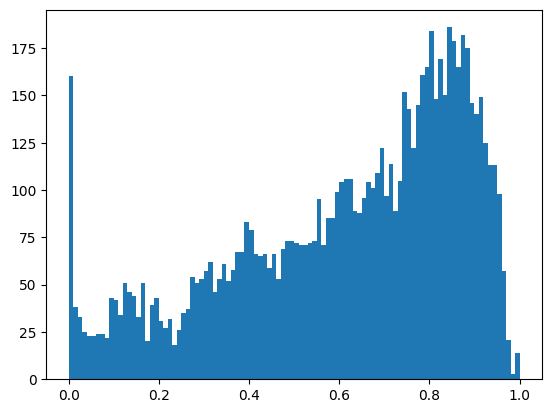

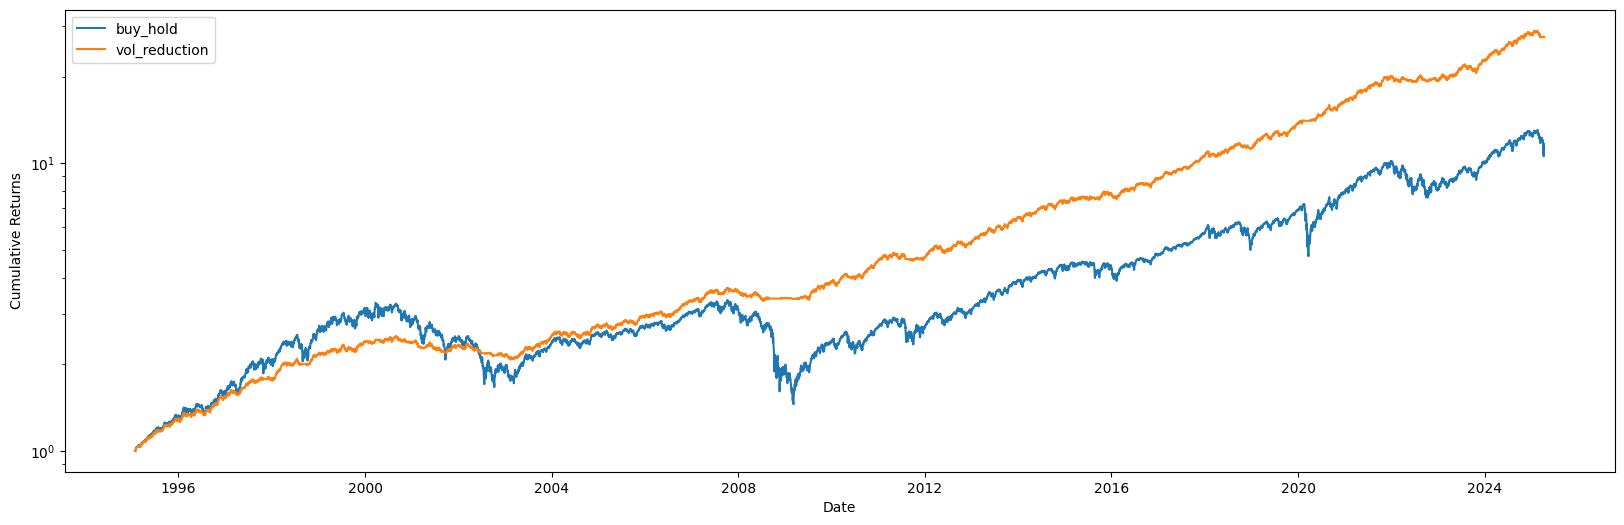

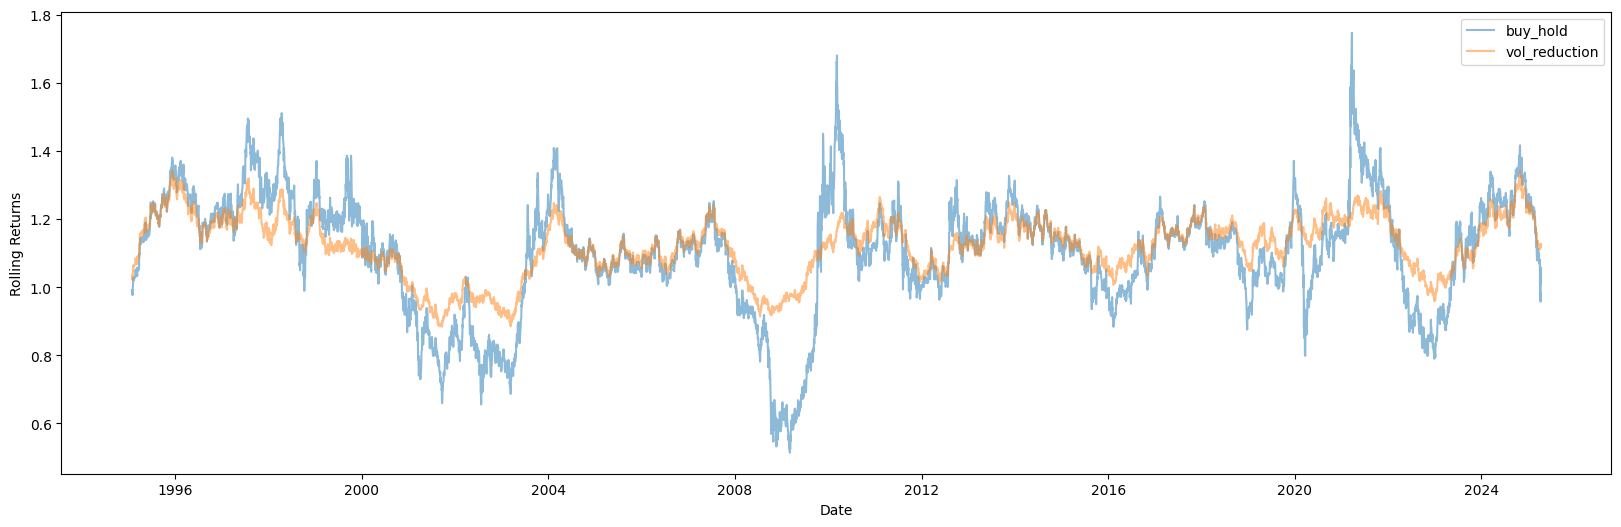

buy_hold
CAGR:           8.39%
Volatility:     19.22%
Sharpe Ratio:   0.44
--------------------------------------------
vol_reduction
CAGR:           11.61%
Volatility:     7.79%
Sharpe Ratio:   1.49
--------------------------------------------
TLT


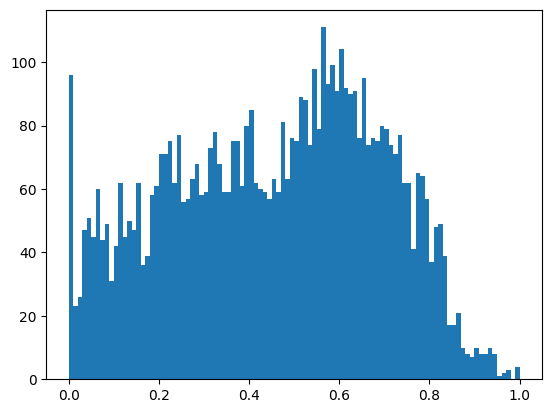

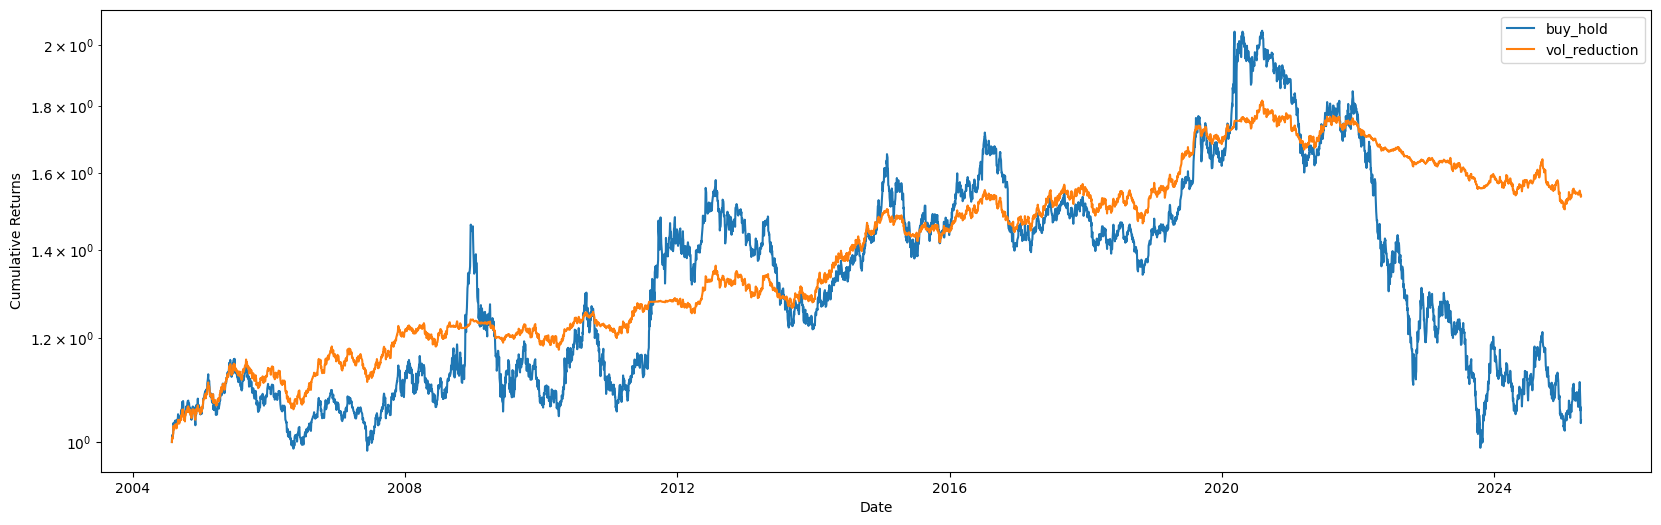

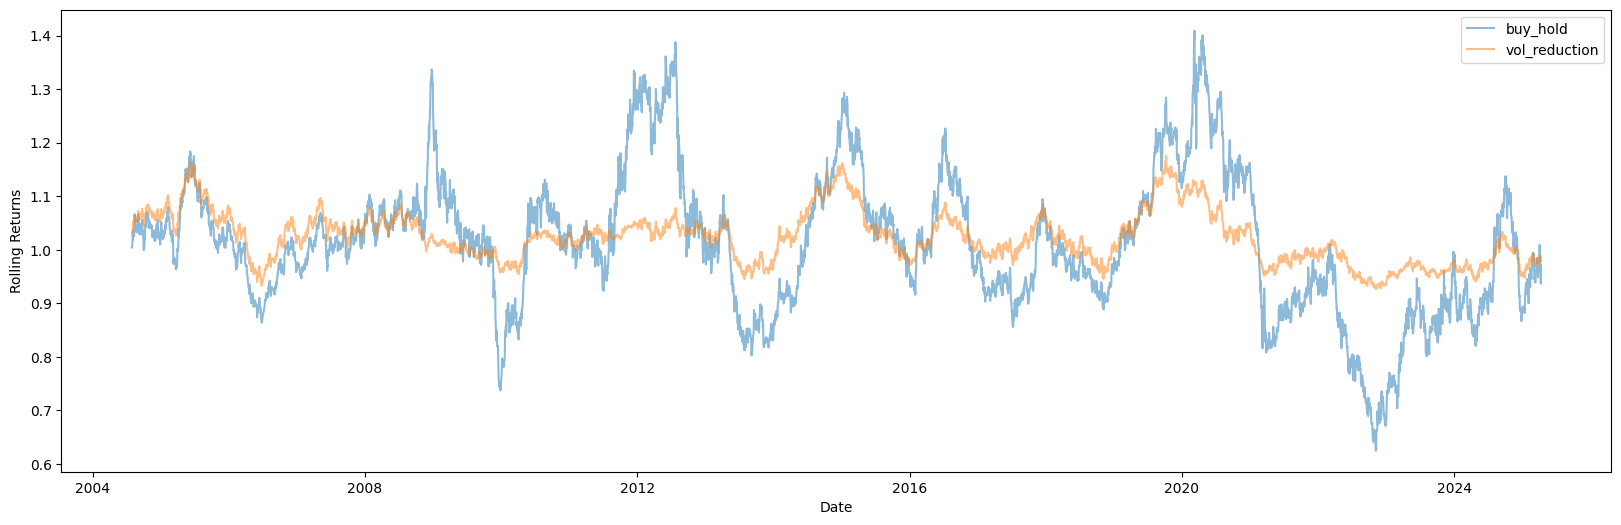

buy_hold
CAGR:           0.19%
Volatility:     14.73%
Sharpe Ratio:   0.01
--------------------------------------------
vol_reduction
CAGR:           2.10%
Volatility:     5.25%
Sharpe Ratio:   0.40
--------------------------------------------
GLD


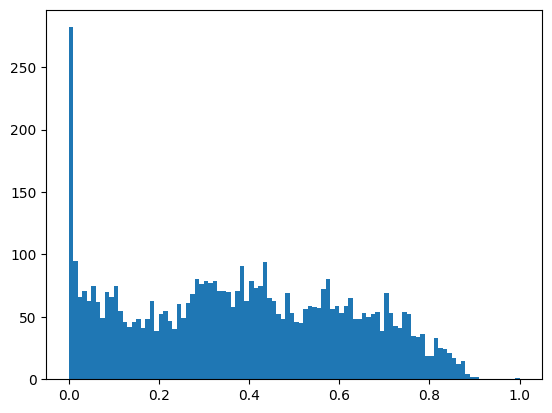

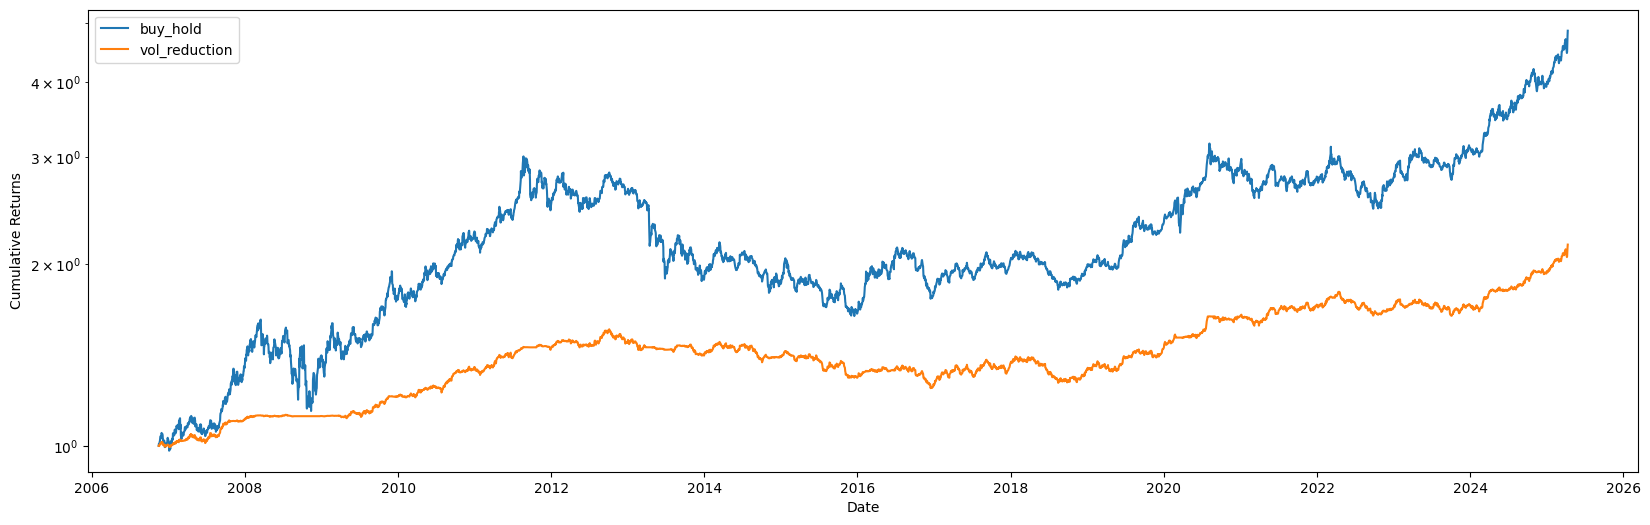

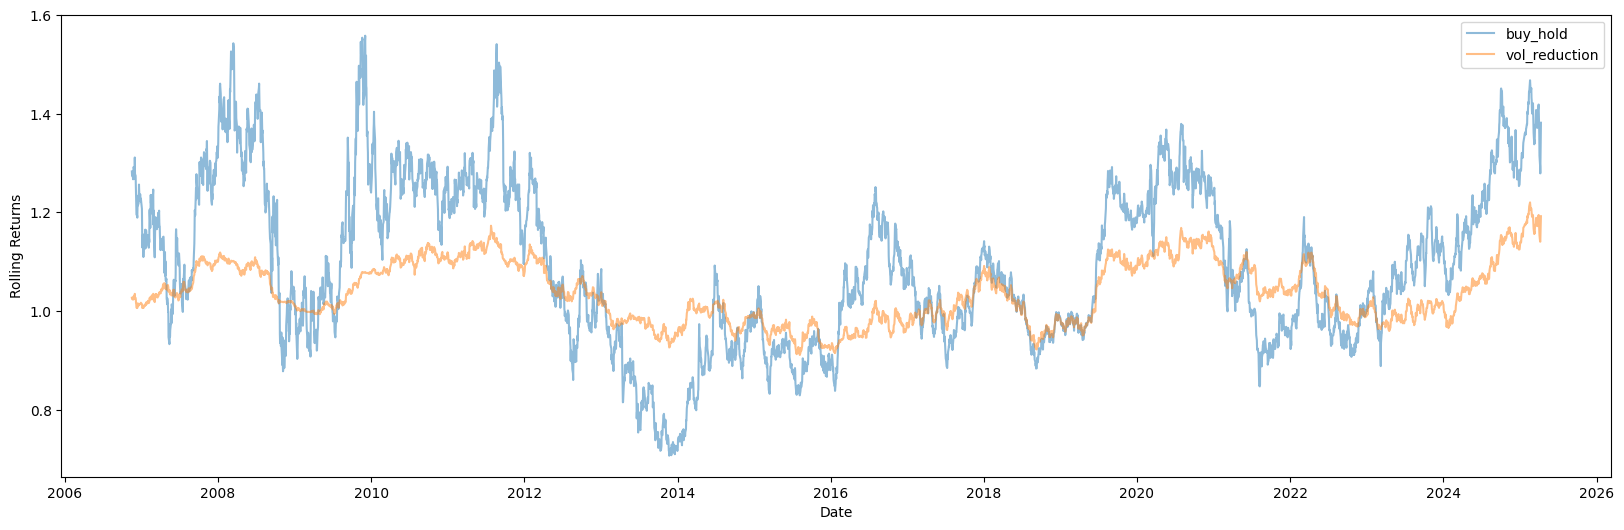

buy_hold
CAGR:           8.99%
Volatility:     17.33%
Sharpe Ratio:   0.52
--------------------------------------------
vol_reduction
CAGR:           4.26%
Volatility:     5.22%
Sharpe Ratio:   0.82
--------------------------------------------


In [46]:
class VolStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""

    params = (
        ('rebalance_period', 21),  # Rebalance period in days
        ('df_vol', pd.DataFrame()),
    )

    def __init__(self):
        super().__init__()
        self.rebalance_day = 0
        self.df_vol = self.p.df_vol
        if 'var_forward_scaled' not in self.df_vol.columns:
            raise ValueError("df_vol must have a column 'var_forward_scaled'")

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 1.0
            current_date = self.datetime.date()
            var_scaled = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'var_forward_scaled'].values[0]
            target_size = 1 - var_scaled
            # target_size = 1 if target_size >= 0.8 else target_size / 10
            target_position = (target_size ** 20) * (self.broker.getvalue() / self.data.close[0])
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1



combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()
    plt.hist((1 - df_data['var_forward_scaled'])**20, bins=100)
    plt.show()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        VolStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data[['var_forward_scaled']]
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    
    compare_returns(df_returns=results, col_name=f'vol_reduction')
    compare_returns(plot=True)

### Trend Vol

  0%|          | 0/3 [00:00<?, ?it/s]

SPY


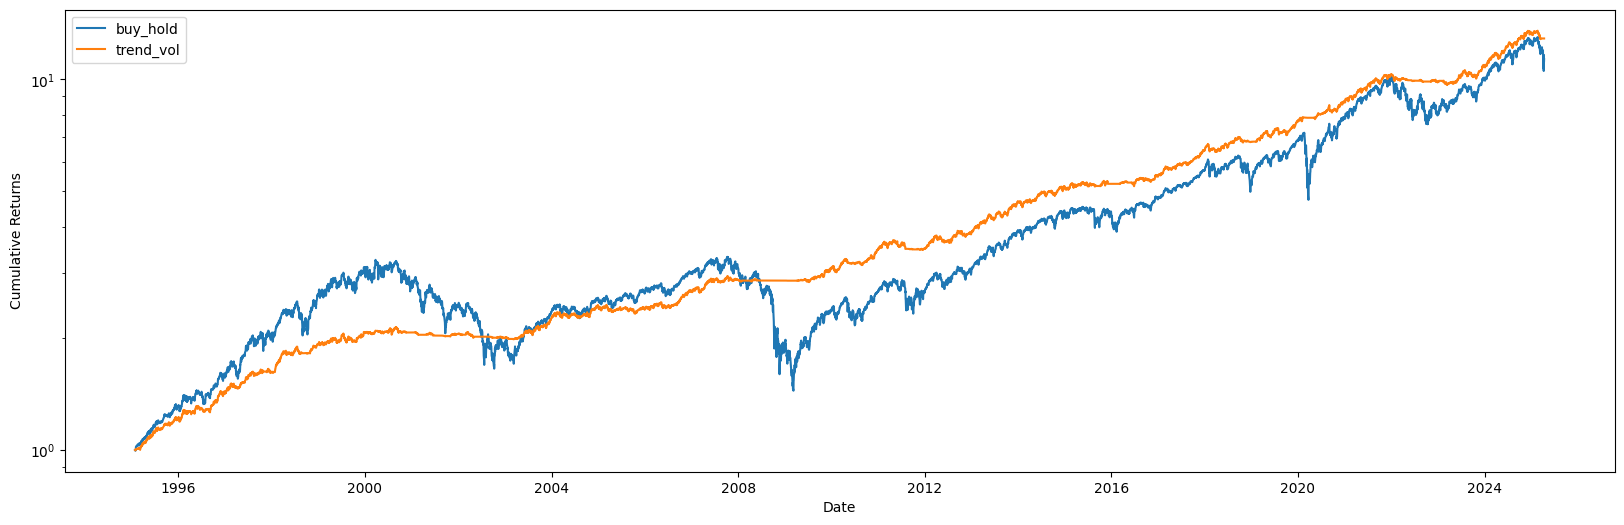

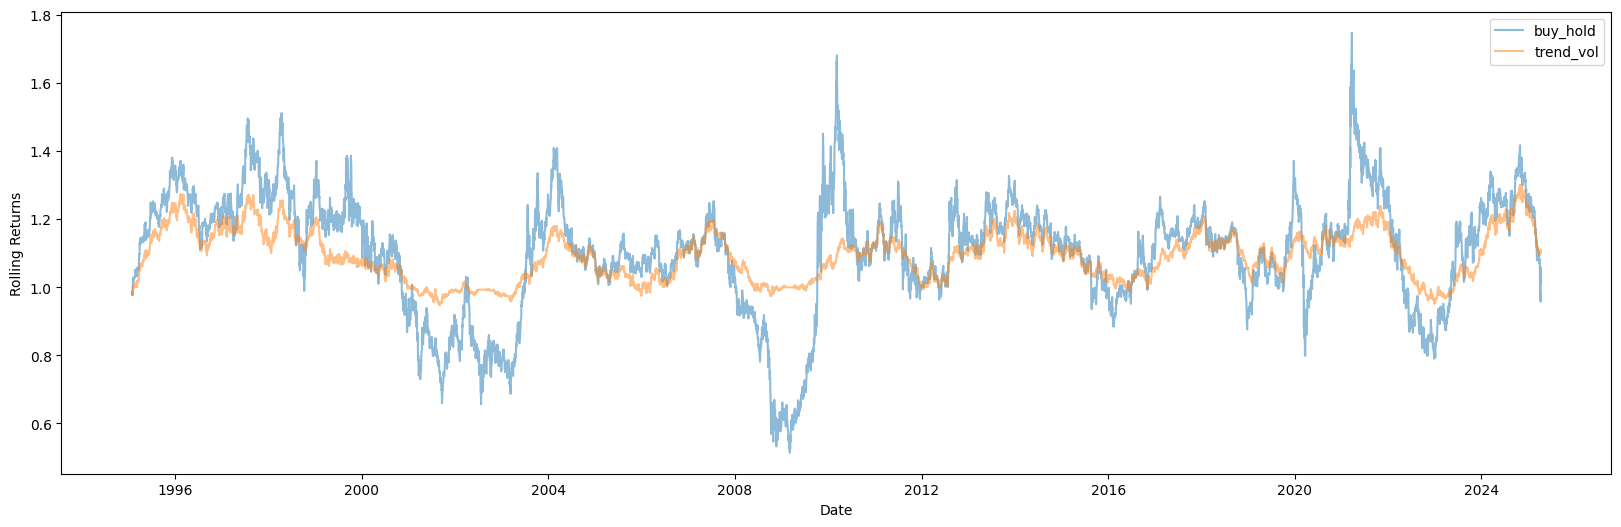

buy_hold
CAGR:           8.38%
Volatility:     19.22%
Sharpe Ratio:   0.44
--------------------------------------------
trend_vol
CAGR:           8.84%
Volatility:     6.36%
Sharpe Ratio:   1.39
--------------------------------------------
TLT


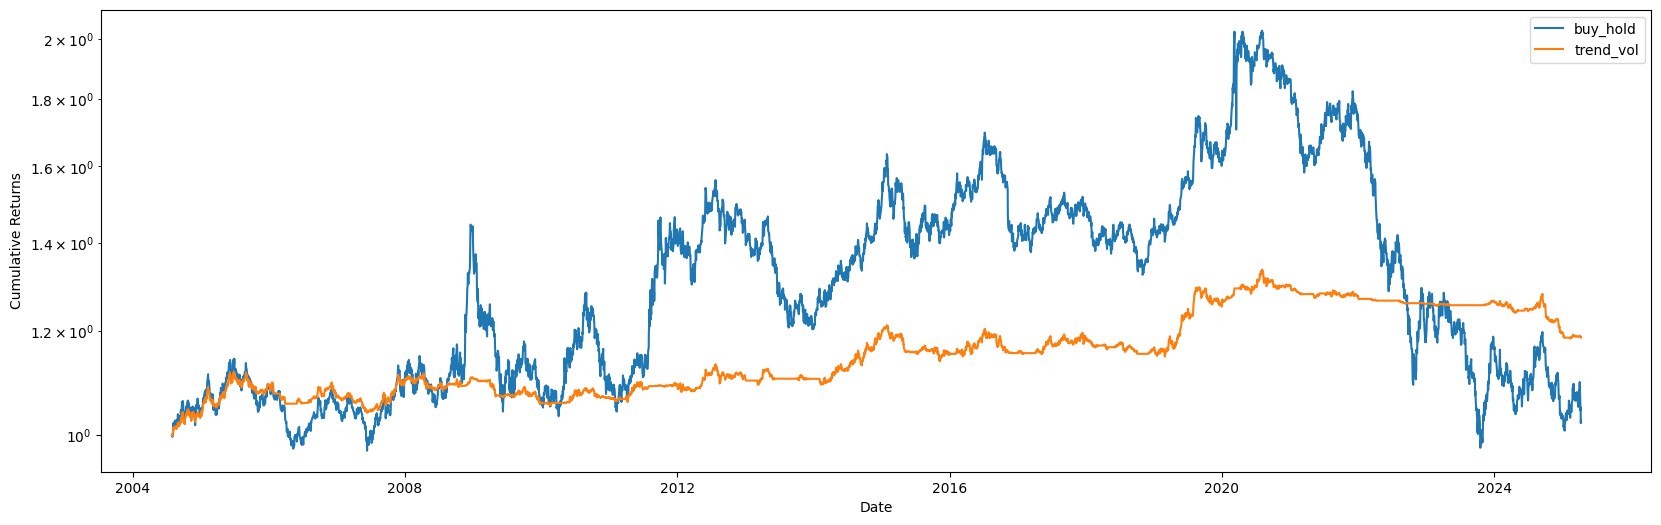

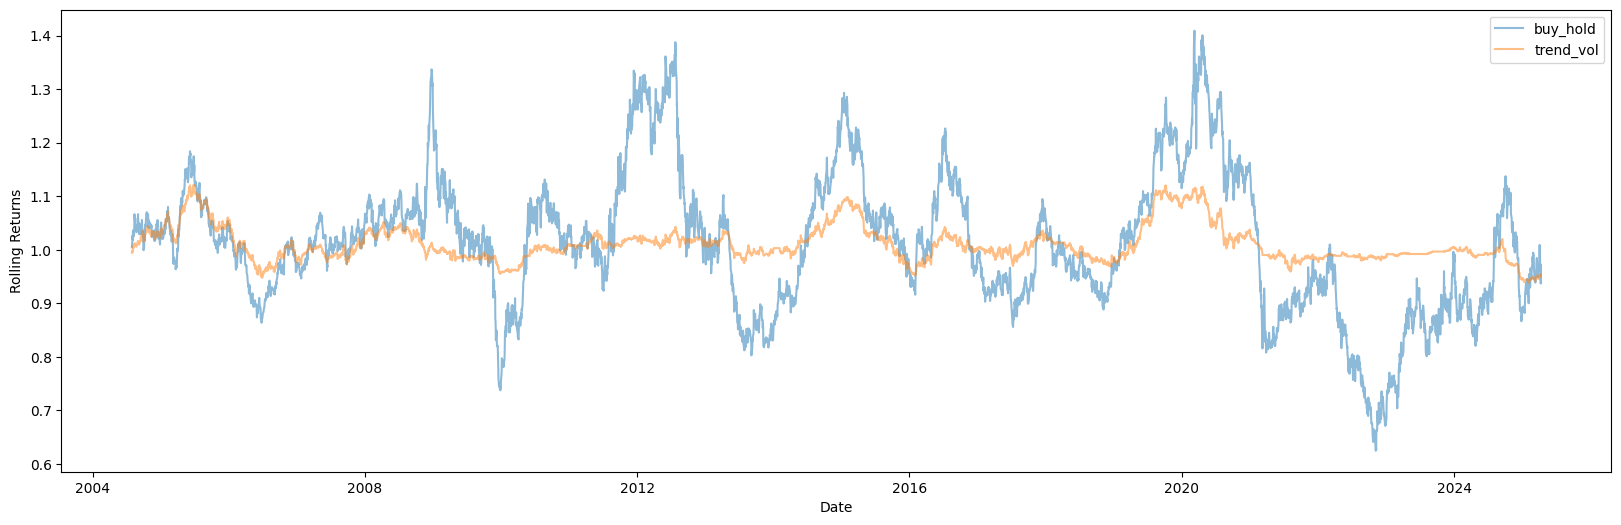

buy_hold
CAGR:           0.13%
Volatility:     14.73%
Sharpe Ratio:   0.01
--------------------------------------------
trend_vol
CAGR:           0.83%
Volatility:     3.38%
Sharpe Ratio:   0.25
--------------------------------------------
GLD


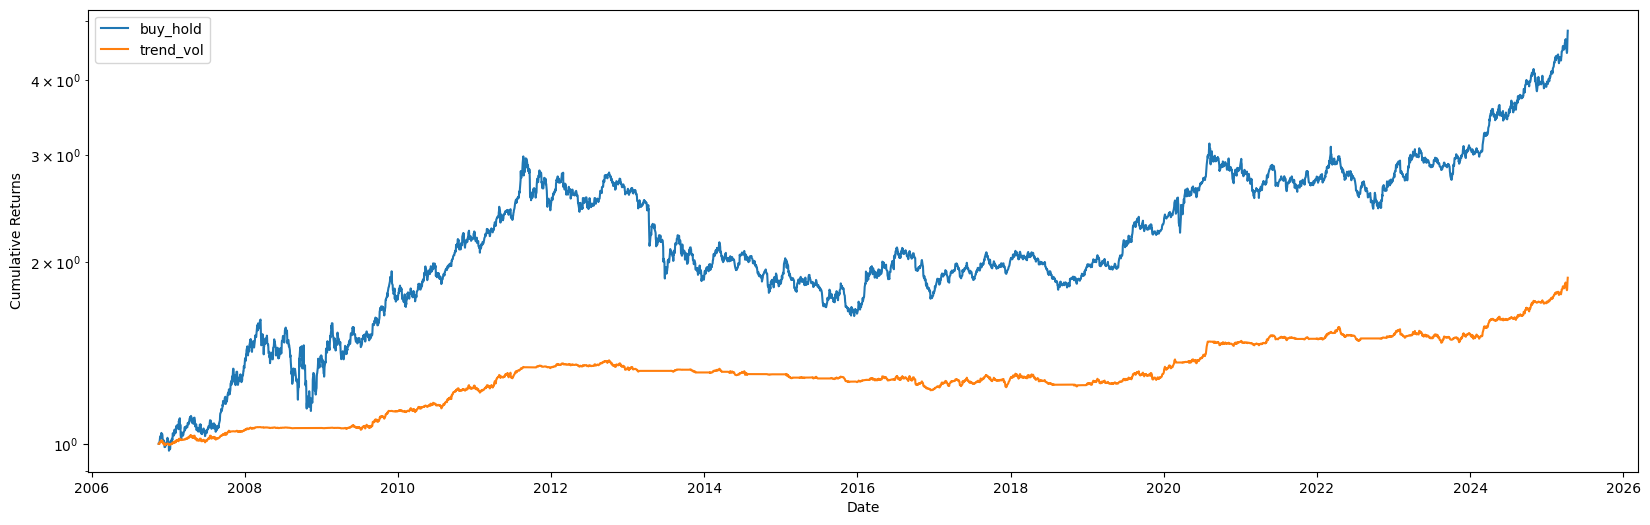

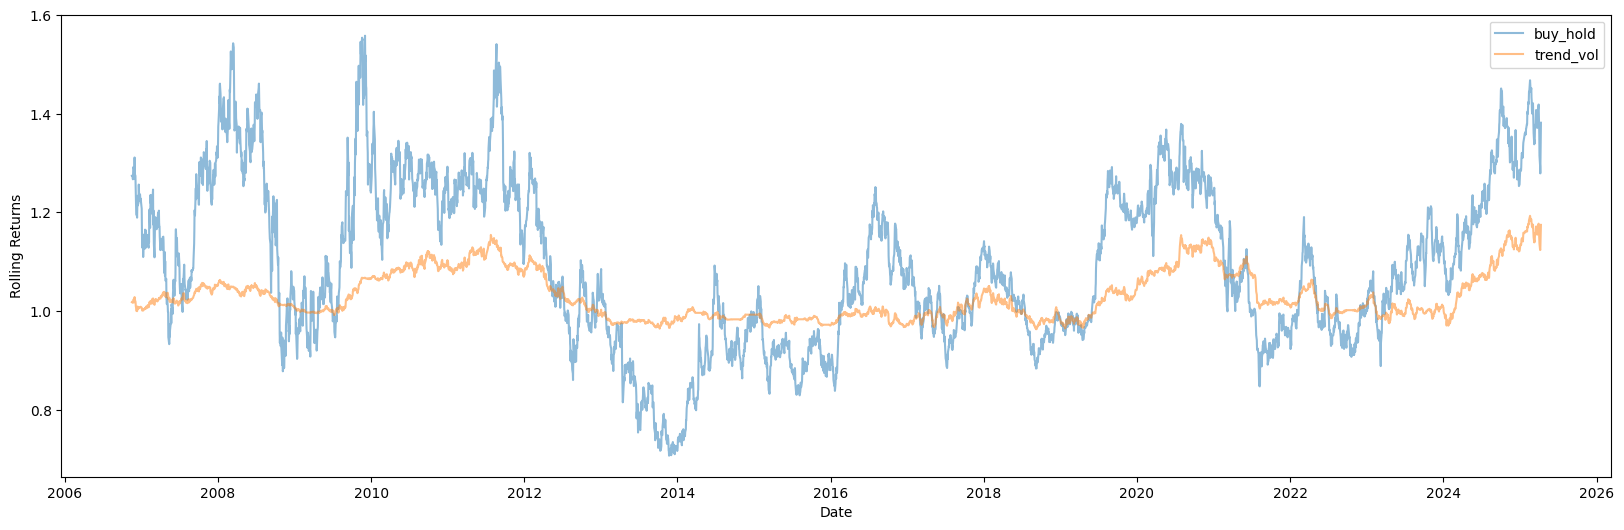

buy_hold
CAGR:           8.94%
Volatility:     17.33%
Sharpe Ratio:   0.52
--------------------------------------------
trend_vol
CAGR:           3.50%
Volatility:     3.66%
Sharpe Ratio:   0.96
--------------------------------------------


In [47]:
class TrendVolStrategy(BaseStrategy):
    """Trend following strategy with configurable lookback period"""
    
    params = (
        ('lookback_periods', [21, 252]),  # Default 1-month lookback (21 trading days)
        ('rebalance_period', 21),  # Rebalance period in days
        ('df_vol', pd.DataFrame()),
    )

    def __init__(self):
        super().__init__()
        self.returns = dict()
        for period in self.p.lookback_periods:
            self.returns[period] = bt.indicators.PercentChange(self.data.close, period=period)
        self.weight = 1 / len(self.p.lookback_periods)
        self.rebalance_day = 0
        self.df_vol = self.p.df_vol
        if 'var_forward_scaled' not in self.df_vol.columns:
            raise ValueError("df_vol must have a column 'var_forward_scaled'")

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_position = self.getposition(self.data).size
            target_size = 0.0        
            for period in self.p.lookback_periods:
                if self.returns[period][0] > 0:
                    target_size += self.weight

            current_date = self.datetime.date()
            var_scaled = self.df_vol.loc[self.df_vol.index == pd.to_datetime(current_date), 'var_forward_scaled'].values[0]
            target_size *= np.clip(1 - var_scaled, 0, 1) ** 20
        
            target_position = target_size * ((self.broker.getvalue() / self.data.close[0]))
            self._submit_order(self.data._name, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1

combined_returns = pd.DataFrame()
for ticker in tqdm(data['asset_list']):

    print(ticker)
    
    df_data = data[ticker]['data'].copy()

    cols = []
    df_display = pd.DataFrame()
    def compare_returns(df_returns=None, col_name=None, plot=False):
        if col_name is not None:
            if col_name not in cols:
                cols.append(col_name)
            df_display[col_name] = df_returns['returns'].copy() + 1
            df_display[f'{col_name}_cum'] = df_display[col_name].cumprod()
            df_display[f'{col_name}_rolling'] = df_display[col_name].rolling(252).apply(lambda x: x.prod())

            df_display.dropna(inplace=True)
            for col in cols:
                df_display[f'{col}_cum'] = df_display[f'{col}_cum'] / df_display[f'{col}_cum'].iloc[0]

        if plot:
            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_cum'], label=col)
            plt.legend()
            plt.yscale('log')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

            plt.figure(figsize=(20, 6))
            for col in cols:
                plt.plot(df_display[f'{col}_rolling'], label=col, alpha=0.5)
            plt.legend()
            plt.xlabel('Date')
            plt.ylabel('Rolling Returns')
            plt.show()

            for col in cols:
                cagr = (df_display[f'{col}_cum'].iloc[-1] / df_display[f'{col}_cum'].iloc[0]) ** (252 / len(df_display)) - 1
                vol = df_display[f'{col}'].std() * np.sqrt(252)
                sr = cagr / vol

                print(col.replace('returns_', ''))
                print(f'CAGR:           {cagr:.2%}')
                print(f'Volatility:     {vol:.2%}')
                print(f'Sharpe Ratio:   {sr:.2f}')
                print('--------------------------------------------')
        

    compare_returns(df_data[['returns']], 'buy_hold')

    # Trend following
    btr = BackTester({ticker: df_data})
    btr.add_strategy(
        TrendVolStrategy, 
        tickers=[ticker], 
        price_data={ticker: df_data}, 
        rebalance_period=rebalance_period, 
        df_vol=df_data[['var_forward_scaled']], 
        lookback_periods=lookback_periods,
    )
    results = btr.backtest()
    returns = results['returns'].copy()
    compare_returns(df_returns=results, col_name=f'trend_vol')

    compare_returns(plot=True)

### Multi-Asset Trend Vol

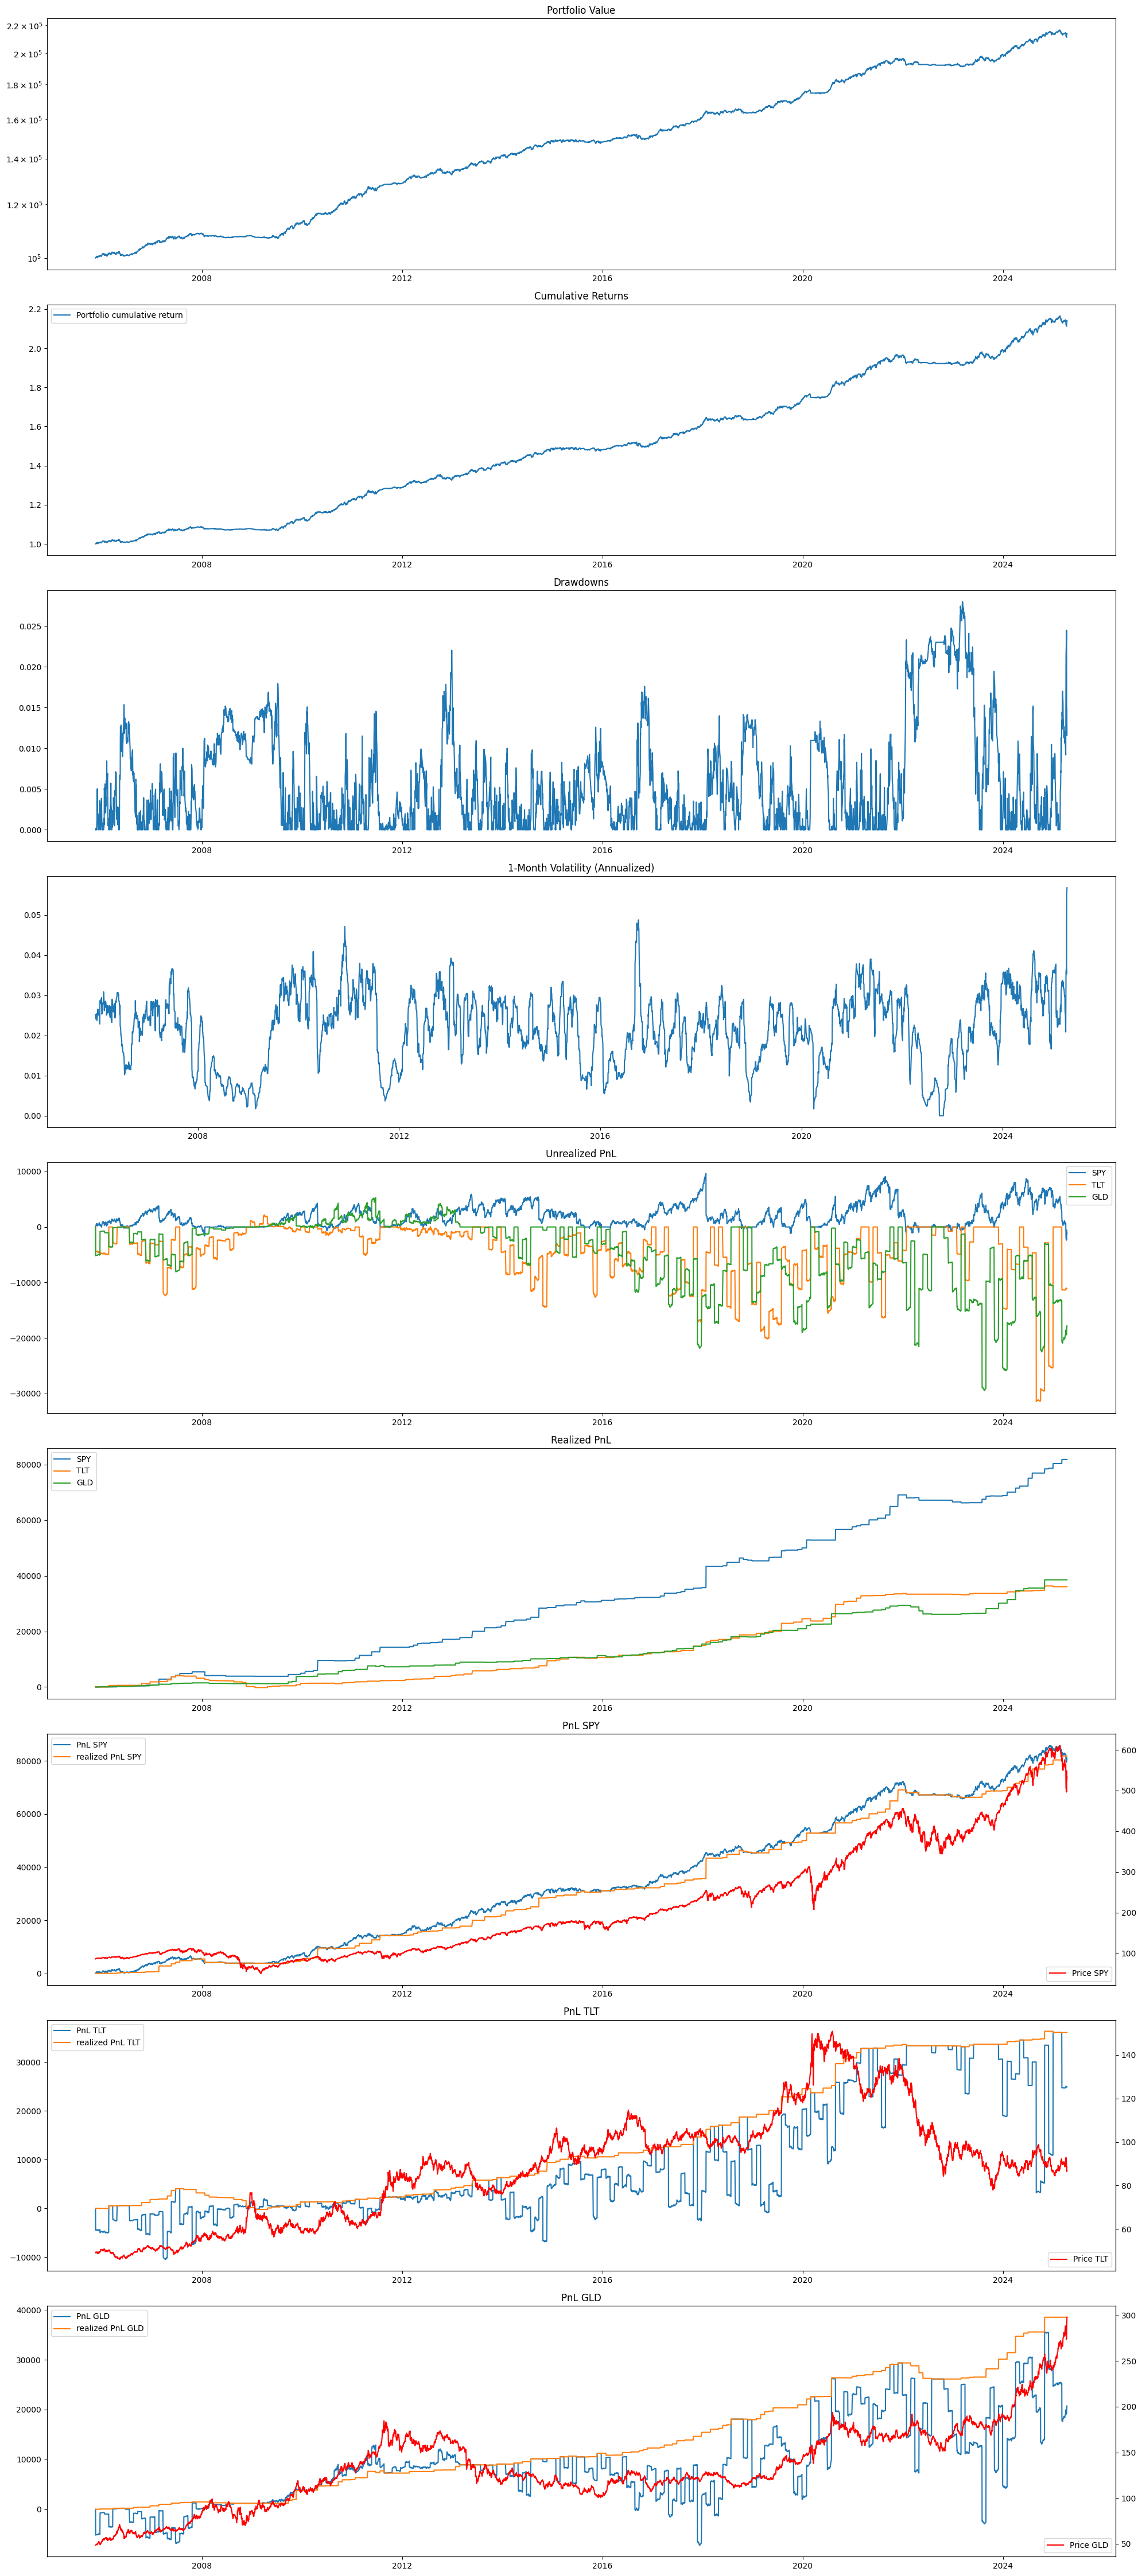

cagr: 0.04
volatility: 0.02
sharpe: 1.70
max_drawdown: 0.03
cumulative_returns: 1.14


In [49]:
class MultiAssetTrendVol(BaseStrategy):

    params = (
        ('lookback_periods', [21, 100, 252]),
        ('rebalance_period', 21),
        ('dfs_vol', dict()),
        ('asset_weights', dict()),
    )

    def __init__(self):
        super().__init__()
        self.returns = dict()
        for ticker in self.p.tickers:
            data = self.getdatabyname(ticker)
            self.returns[ticker] = dict()
            for period in self.p.lookback_periods:
                self.returns[ticker][period] = bt.indicators.PercentChange(data.close, period=period)
        self.weight = 1 / len(self.p.lookback_periods)
        self.rebalance_day = 0
        self.dfs_vol = self.p.dfs_vol
        for ticker in self.p.tickers:
            df_vol = self.dfs_vol[ticker]
            if 'var_forward_scaled' not in df_vol.columns:
                raise ValueError("df_vol must have a column 'var_forward_scaled'")

        
    def next(self):
        super().next()
        if self.rebalance_day % self.p.rebalance_period == 0:
            current_capital = self.broker.getvalue()
            
            current_date = self.datetime.date()
            for ticker in self.p.tickers:
                data = self.getdatabyname(ticker)
                current_position = self.broker.getposition(data).size
                ticker_capital = current_capital * self.p.asset_weights[ticker]
                target_size = 0.0        
                for period in self.p.lookback_periods:
                    if self.returns[ticker][period][0] > 0:
                        target_size += self.weight

                df_vol = self.dfs_vol[ticker]
                var_scaled = df_vol.loc[df_vol.index == pd.to_datetime(current_date), 'var_forward_scaled'].values[0]
                target_size *= np.clip(1 - var_scaled, 0, 1) ** 20
        
                target_position = target_size * ((ticker_capital / self.data.close[0]))
                self._submit_order(ticker, target_position - current_position, self.data.close[0])
        self.rebalance_day += 1
    
btr = BackTester({ticker: data[ticker]['data'] for ticker in data['asset_list']})
btr.add_strategy(
    MultiAssetTrendVol, 
    tickers=data['asset_list'], 
    price_data={ticker: data[ticker]['data'] for ticker in data['asset_list']}, 
    rebalance_period=rebalance_period, 
    dfs_vol={ticker: data[ticker]['data'] for ticker in data['asset_list']}, 
    lookback_periods=lookback_periods,
    asset_weights={'SPY': 0.34, 'TLT': 0.33, 'GLD': 0.33},
)
results = btr.backtest()
btr.plot_results()
for key in results:
    if key == 'returns': continue
    print(f"{key}: {results[key]:.2f}")

## HRP allocation

In [32]:
from pypfopt import HRPOpt

def hierarchical_risk_parity_allocation(asset_dfs):
    """
    Perform Hierarchical Risk Parity (HRP) asset allocation given multiple dataframes of asset returns.

    Parameters:
    asset_dfs (list of pd.DataFrame): List of dataframes, each containing 'dates' and 'returns' columns.

    Returns:
    dict: Asset allocation weights with generated asset names as keys.
    """
    processed_series = []
    
    # Process each asset dataframe to create return series with unique names
    for ticker in asset_dfs:
        df = asset_dfs[ticker].copy()
        # df['date'] = pd.to_datetime(df['date'])
        # df.set_index('date', inplace=True)
        df = df[~df.index.duplicated(keep='first')]  # Remove duplicate dates
        asset_name = ticker
        processed_series.append(df['returns'].rename(asset_name))
    
    # Combine all series into a single dataframe with inner join
    combined_df = pd.concat(processed_series, axis=1, join='inner')

    # display(combined_df)
    
    if combined_df.empty:
        raise ValueError("No common dates found across all assets")
    
    # Calculate HRP weights
    hrp = HRPOpt(combined_df)
    hrp_weights = hrp.optimize()
    
    return hrp_weights

asset_dfs = dict()
for ticker in data['asset_list']:
    df = data[ticker]['data'][['returns']].copy()
    # df['returns'] = combined_returns[ticker].copy()
    df.dropna(inplace=True)
    asset_dfs[ticker] = df

hrp_weights = hierarchical_risk_parity_allocation(asset_dfs)


for ticker in data['asset_list']:
    data[ticker]['hrp_weight'] = hrp_weights[ticker]
    print(f"{ticker}: {hrp_weights[ticker]}")



# combined_returns.dropna(inplace=True)
# combined_ret_arr = []
# for i, r in combined_returns.iterrows():
#     combined_ret = 0
#     for ticker in data['asset_list']:
#         combined_ret += r[ticker] * hrp_weights[ticker]
#     combined_ret_arr.append(combined_ret)

# combined_returns['combined_ret'] = combined_ret_arr
# combined_returns['combined_ret_cum'] = (combined_returns['combined_ret']).cumprod()

# cagr = (combined_returns['combined_ret_cum'][-1] ** (252 / len(combined_returns))) - 1
# print(f"CAGR: {cagr:.2%}")
# vol = combined_returns['combined_ret'].std() * np.sqrt(252)
# print(f"Volatility: {vol:.2%}")
# sharpe = cagr / vol
# print(f"Sharpe Ratio: {sharpe:.2f}")
# drawdown = combined_returns['combined_ret_cum'] / np.maximum.accumulate(combined_returns['combined_ret_cum']) - 1
# max_drawdown = np.min(drawdown)
# print(f"Max Drawdown: {max_drawdown:.2%}")

# plt.figure(figsize=(20, 6))
# plt.plot(combined_returns.index, combined_returns['combined_ret_cum'])
# plt.xlabel('Date')
# plt.ylabel('Cumulative Return')
# plt.yscale('log')
# plt.show()

# plt.figure(figsize=(20, 6))
# plt.plot(combined_returns.index, drawdown)
# plt.xlabel('Date')
# plt.ylabel('Drawdown')
# plt.show()

# # for ticker in data['asset_list']:
# #     df = data[ticker]['data'].copy()
# #      hrp_weights[ticker]

SPY: 0.28629704363933817
TLT: 0.41644316466882514
GLD: 0.2972597916918367


## Forecast Volatility

(8085, 2)


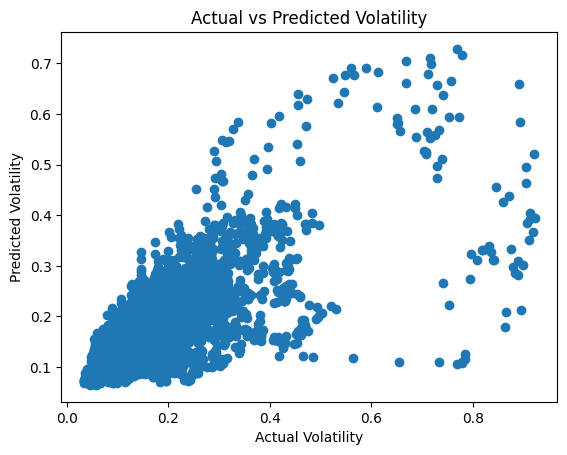

(5692, 1)


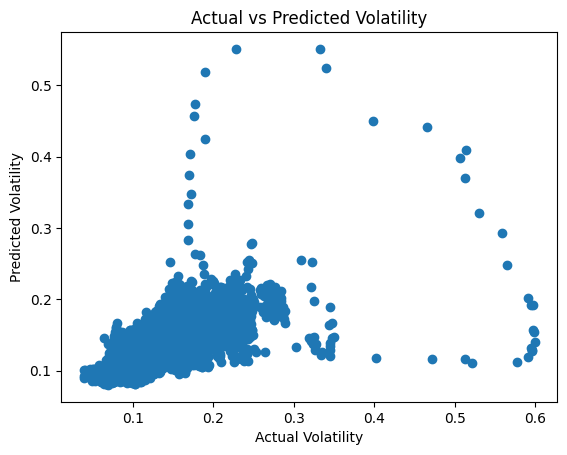

(4221, 2)


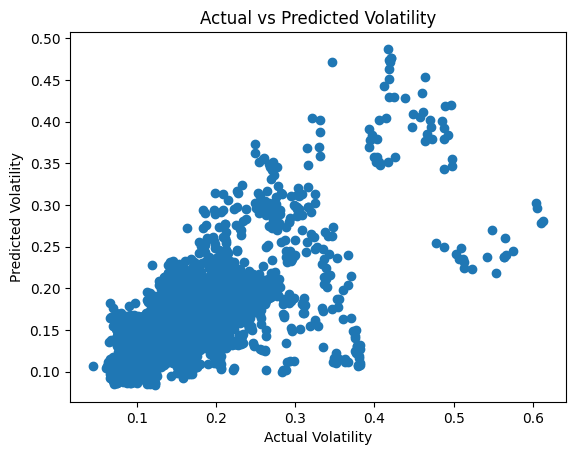

In [21]:

target_positions = {}
for ticker in data['asset_list']:
    # display(data[ticker]['data'])

    df = data[ticker]['data'].copy()   
    
    df_train = df.dropna().copy()
    y = df_train['vol_forward'].to_numpy()
    X = []
    if 'vix' in df:
        X .append(df_train['vix'].to_numpy().reshape(-1, 1))
    if 'ATR' in df:
        X.append(df_train['ATR'].to_numpy().reshape(-1, 1))
    X = np.concatenate(X, axis=1)
    print(X.shape)
       
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    plt.scatter(y, y_pred)
    plt.xlabel('Actual Volatility')
    plt.ylabel('Predicted Volatility')
    plt.title('Actual vs Predicted Volatility')
    plt.show()

    data[ticker]['vol_model'] = model




## Trade strategy

In [39]:
sum_weights = 0
for ticker in data['asset_list']:

    df = data[ticker]['data'].copy()
    print('-----------------------------------')
    print(f'ticker: {ticker}, date: {df.index[-1]}')
    vol_input = []
    if 'vix' in df:
        vix = df['vix'].to_list()[-1]
        vol_input.append(vix)
    if 'ATR' in df:
        atr = df['ATR'].to_list()[-1]
        vol_input.append(atr)
    
    vol_input =  np.array([vol_input])
    # print(vol_input.shape)
    forward_vol = data[ticker]['vol_model'].predict(vol_input)[0]
    forward_var = forward_vol ** 2
    forward_var_scaled = data[ticker]['var_scaler'].transform(np.array([forward_var]).reshape(-1, 1))[0][0]
    # print(forward_var_scaled)

    target_position = 0
    weight = 1 / len(lookback_periods)
    for period in lookback_periods:
        df[f'ret_{period}'] = calculate_returns(df, period)
        ret = df[f'ret_{period}'].to_list()[-1]
        print(f'ret_{period}: {ret:.2%}')
        if ret > 0:
            target_position += 1 * weight
    print(f"target_position: {target_position:.2f} x {1 - forward_var_scaled:.2f} = {target_position * (1 - forward_var_scaled):.2f}")
    target_position *= (1 - forward_var_scaled)


    # weight = data[ticker]['hrp_weight'] * target_position
    weight = (1 / len(data['asset_list'])) * target_position
    sum_weights += weight
    num_shares = int((weight * capital) / df['close'].to_list()[-1])

    
    print(f'num_shares: {num_shares}')

df = data['SHV']['data'].copy()
num_shares = int((1 - sum_weights) * capital / df['close'].to_list()[-1])
num_shares = max(num_shares, 0)
print('-----------------------------------')
print(f'ticker: SHV, date: {df.index[-1]}')
print(f'num_shares: {num_shares}')

-----------------------------------
ticker: SPY, date: 2025-04-11 00:00:00
ret_21: -5.13%
ret_100: -8.85%
ret_252: 3.08%
target_position: 0.33 x 0.82 = 0.27
num_shares: 10
-----------------------------------
ticker: TLT, date: 2025-04-11 00:00:00
ret_21: -3.64%
ret_100: -3.54%
ret_252: -3.25%
target_position: 0.00 x 0.87 = 0.00
num_shares: 0
-----------------------------------
ticker: GLD, date: 2025-04-11 00:00:00
ret_21: 8.24%
ret_100: 25.93%
ret_252: 35.55%
target_position: 1.00 x 0.87 = 0.87
num_shares: 61
-----------------------------------
ticker: SHV, date: 2025-04-11 00:00:00
num_shares: 352


# END